# Example 2 — Neutrino-electron elastic scattering with `neptune`

`neptune` ships a small, analytic engine for the elastic $\nu_\alpha + e^- \to \nu_\alpha + e^-$ process. We support:

* **Standard Model** ($W$ + $Z$): ν_e/ν̄_e get the CC enhancement, ν_μ / ν_τ are NC-only.
* **BSM $Z'$**: a vector mediator that couples to the neutrino with charge $Q_V$ and to the electron with charge $Q_L$. The BSM piece corrects the SM vector coupling as
$$
C_v \to C_v + \frac{Q_V Q_L g'^2}{(M_{Z'}^2 + 2 m_e T_e)\,2\sqrt{2}\,G_F}\,.
$$

The differential cross section is
$$
\frac{d\sigma}{dT_e} = \frac{2\,m_e\,G_F^2}{\pi}\bigl[ C_L^2 + C_R^2 (1 - T_e/E_\nu)^2 - C_L C_R \frac{m_e T_e}{E_\nu^2} \bigr]\,,
$$
with $C_L = (C_v + C_a)/2$ and $C_R = (C_v - C_a)/2$ (swap for antineutrinos).

This notebook shows:
1. Total cross sections for ν_e, ν_μ, ν̄_e, ν̄_μ.
2. The differential recoil spectrum $d\sigma/dT_e$.
3. The BSM modification.
4. Generating events with full lab-frame 4-vectors in a DarkNews-compatible `pandas.DataFrame`.
5. Folding in a neutrino flux.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import neptune as nep
from neptune import const
print('neptune', nep.__version__)

neptune 0.1.0


## 1) Total cross sections vs energy

The $\nu_e$ cross section is roughly an order of magnitude larger than $\nu_\mu$ because of the CC interference.  Antineutrino cross sections are about $\sim 1/3$ of their neutrino counterparts at fixed energy.

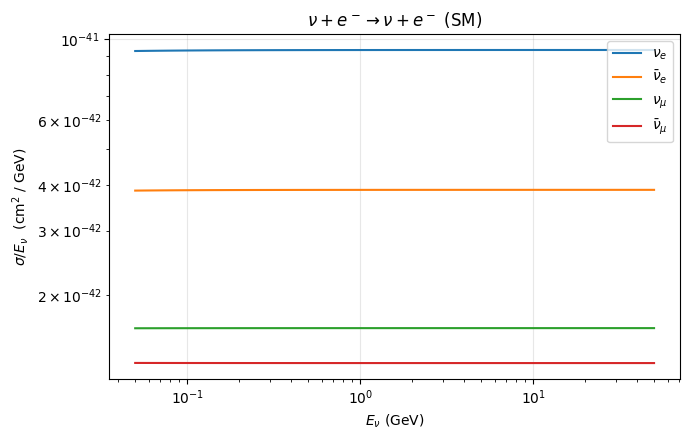

In [2]:
models = {
    r'$\nu_e$':       nep.NuElectronSMModel(nu_flavor='e',  is_nubar=False),
    r'$\bar\nu_e$':   nep.NuElectronSMModel(nu_flavor='e',  is_nubar=True),
    r'$\nu_\mu$':     nep.NuElectronSMModel(nu_flavor='mu', is_nubar=False),
    r'$\bar\nu_\mu$': nep.NuElectronSMModel(nu_flavor='mu', is_nubar=True),
}
Enu = np.geomspace(0.05, 50.0, 100)
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, m in models.items():
    sigma = m.total_xsec(Enu)        # cm^2
    ax.plot(Enu, sigma / Enu, label=label)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$E_\nu$ (GeV)')
ax.set_ylabel(r'$\sigma / E_\nu$  (cm$^2$ / GeV)')
ax.set_title(r'$\nu + e^- \to \nu + e^-$ (SM)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## 2) Differential recoil spectrum

At fixed $E_\nu$ the spectrum $d\sigma/dT_e$ is roughly flat between zero and the kinematic limit
$T_e^{\max} = 2 E_\nu^2 / (m_e + 2 E_\nu) \approx E_\nu$ for $E_\nu \gg m_e$, with a slope set by the $C_L,\,C_R$ structure.

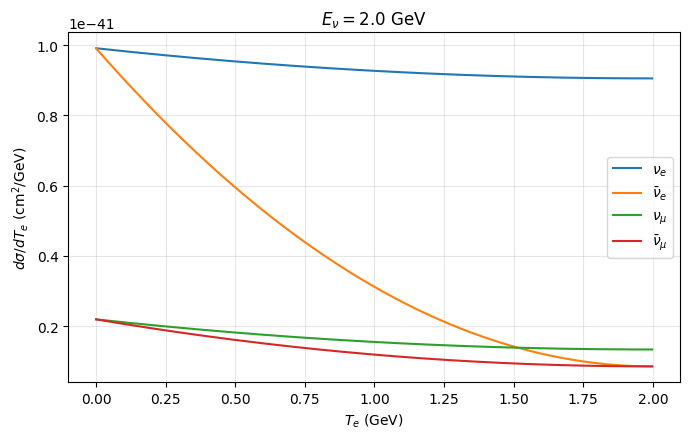

In [3]:
Enu0 = 2.0
Te = np.linspace(1e-4, nep.nu_electron.Te_max(Enu0) * 0.999, 400)
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, m in models.items():
    ds = m.dsigma_dTe(Enu0, Te)
    ax.plot(Te, ds, label=label)
ax.set_xlabel(r'$T_e$ (GeV)')
ax.set_ylabel(r'$d\sigma/dT_e$ (cm$^2$/GeV)')
ax.set_title(rf'$E_\nu = {Enu0}$ GeV')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## 3) BSM $Z'$ effect

We turn on a vector $Z'$ with $L_\mu - L_\tau$-style charges ($Q_V = Q_L = 1$) and pick a benchmark $M_{Z'} = 50\,\mathrm{MeV}$, $g' = 5\times10^{-4}$. The BSM piece shows up as a low-recoil enhancement: $T_e \sim M_{Z'}^2 / (2 m_e)$ is the propagator scale.

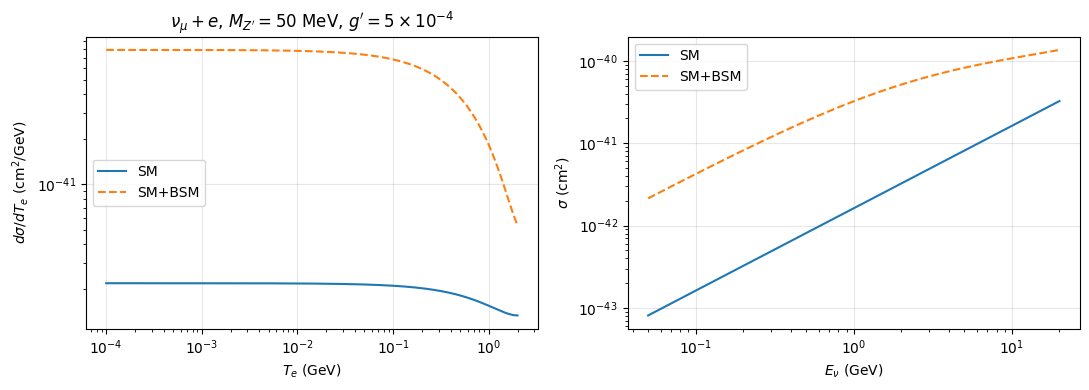

In [4]:
sm_nu_mu  = nep.NuElectronSMModel(nu_flavor='mu')
bsm_nu_mu = nep.NuElectronBSMModel(
    nu_flavor='mu', is_nubar=False,
    mzprime=0.05, gprime=5e-4, QV=1.0, QL=1.0,
)
Enu0 = 2.0
Te = np.geomspace(1e-4, nep.nu_electron.Te_max(Enu0) * 0.999, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(Te, sm_nu_mu.dsigma_dTe(Enu0, Te),  label='SM',    lw=1.5)
axes[0].plot(Te, bsm_nu_mu.dsigma_dTe(Enu0, Te), label='SM+BSM', lw=1.5, ls='--')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel(r'$T_e$ (GeV)'); axes[0].set_ylabel(r'$d\sigma/dT_e$ (cm$^2$/GeV)')
axes[0].set_title(r"$\nu_\mu + e$, $M_{Z'}=50$ MeV, $g'=5\times10^{-4}$")
axes[0].legend(); axes[0].grid(alpha=0.3)

Enu_grid = np.geomspace(0.05, 20.0, 50)
axes[1].plot(Enu_grid, sm_nu_mu.total_xsec(Enu_grid),  label='SM',     lw=1.5)
axes[1].plot(Enu_grid, bsm_nu_mu.total_xsec(Enu_grid), label='SM+BSM', lw=1.5, ls='--')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel(r'$E_\nu$ (GeV)'); axes[1].set_ylabel(r'$\sigma$ (cm$^2$)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()

## 4) Event generation with full 4-vectors

`NuElectronGenerator` produces a DarkNews-style `pandas.DataFrame` with MultiIndex columns. The 4-momenta of the incoming neutrino, electron-at-rest target, outgoing electron and outgoing neutrino are stored as `P_projectile`, `P_target`, `P_decay_ell_minus`, `P_decay_N_daughter` (matching the DarkNews naming convention so notebooks can be shared across both packages).

In [5]:
model = nep.NuElectronSMModel(nu_flavor='e', is_nubar=False)
gen = nep.NuElectronGenerator(
    model, Enu=2.0, T_min=1e-3, n_events=20_000, seed=0,
)
df = gen.generate()
print('Columns (top level):', sorted({c[0] for c in df.columns}))
print(f'Total events: {len(df)}')
print(f'Sum of weights (= total xsec): {df[("w_event_rate","")].sum() / len(df) :.3e} cm^2')
print(f'Reference total xsec:           {model.total_xsec(2.0, T_min=1e-3):.3e} cm^2')
df.head()

Columns (top level): ['Enu', 'P_decay_N_daughter', 'P_decay_ell_minus', 'P_projectile', 'P_target', 'Te', 'theta_e', 'w_event_rate']
Total events: 20000
Sum of weights (= total xsec): 1.866e-41 cm^2
Reference total xsec:           1.866e-41 cm^2


P_projectile                 P_target                P_decay_ell_minus  \
             0    1    2    3         0    1    2    3                 0   
0          2.0  0.0  0.0  2.0  0.000511  0.0  0.0  0.0          1.274635   
1          2.0  0.0  0.0  2.0  0.000511  0.0  0.0  0.0          0.540746   
2          2.0  0.0  0.0  2.0  0.000511  0.0  0.0  0.0          0.083407   
3          2.0  0.0  0.0  2.0  0.000511  0.0  0.0  0.0          0.034546   
4          2.0  0.0  0.0  2.0  0.000511  0.0  0.0  0.0          1.627030   

                                P_decay_N_daughter                      \
          1         2         3                  0         1         2   
0  0.020772 -0.006404  1.274449           0.725876 -0.020772  0.006404   
1 -0.020008  0.001629  0.540373           1.459765  0.020008 -0.001629   
2 -0.003299 -0.008386  0.082917           1.917104  0.003299  0.008386   
3 -0.005148  0.002772  0.034043           1.965965  0.005148 -0.002772   
4  0.009847 -0.014604  1.626935           0.373481 -0.009847  0.014604   

             Enu        Te   theta_e  w_event_rate  
          3                                         
0  0.725551  2.0  1.274124  0.017054  1.831752e-41  
1  1.459627  2.0  0.540235  0.037131  1.900527e-41  
2  1.917083  2.0  0.082896  0.108257  1.966726e-41  
3  1.965957  2.0  0.034035  0.170102  1.974858e-41  
4  0.373065  2.0  1.626519  0.010826  1.815129e-41

We can plot the recoil $T_e$ and scattering angle $\theta_e$ from the generated 4-vectors (and verify they reproduce the analytic $d\sigma/dT_e$ shape).

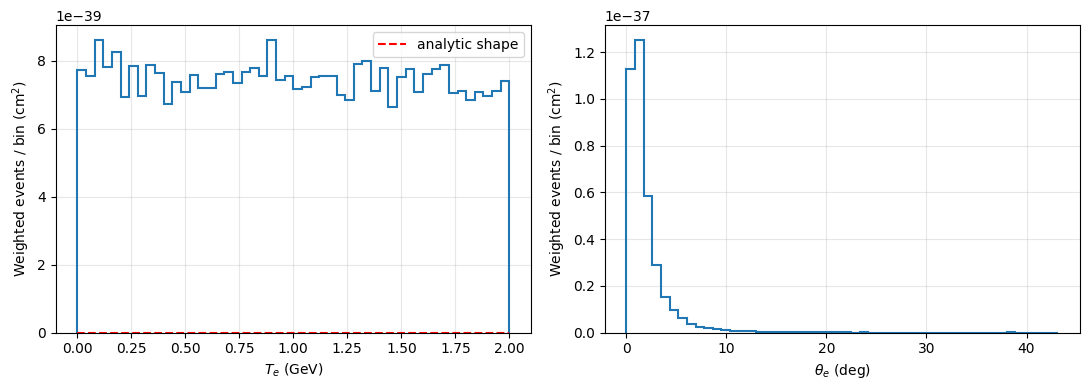

In [6]:
Te = df[('Te', '')].values
th = df[('theta_e', '')].values
w  = df[('w_event_rate', '')].values

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(Te, bins=50, weights=w, histtype='step', lw=1.5)
Te_ref = np.linspace(1e-3, nep.nu_electron.Te_max(2.0) * 0.999, 200)
ds_ref = model.dsigma_dTe(2.0, Te_ref)
scale = (Te.max() - Te.min()) / 50  # bin width to convert dσ/dT to events/bin
axes[0].plot(Te_ref, ds_ref * scale, 'r--', label='analytic shape')
axes[0].set_xlabel(r'$T_e$ (GeV)')
axes[0].set_ylabel('Weighted events / bin (cm$^2$)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(np.degrees(th), bins=50, weights=w, histtype='step', lw=1.5)
axes[1].set_xlabel(r'$\theta_e$ (deg)')
axes[1].set_ylabel('Weighted events / bin (cm$^2$)')
axes[1].grid(alpha=0.3)
plt.tight_layout()

**Sanity check** — the generated 4-vectors satisfy energy/momentum conservation up to floating-point error:

In [7]:
Pin  = (df['P_projectile'].values + df['P_target'].values).astype(float)
Pout = (df['P_decay_ell_minus'].values + df['P_decay_N_daughter'].values).astype(float)
diff = np.abs(Pin - Pout).max()
print(f'max |P_in - P_out| over all events: {diff:.2e} GeV  (should be ~1e-15)')

max |P_in - P_out| over all events: 0.00e+00 GeV  (should be ~1e-15)


## 5) Folding in a neutrino flux

If you have a beam flux $d\Phi/dE_\nu$, pass a callable as `flux=` and an energy window as `Emin/Emax`. We illustrate with a toy ν_μ Gaussian peaked at 800 MeV.

flux-averaged xsec (T_e > 50 MeV): 1.201e-42 cm^2


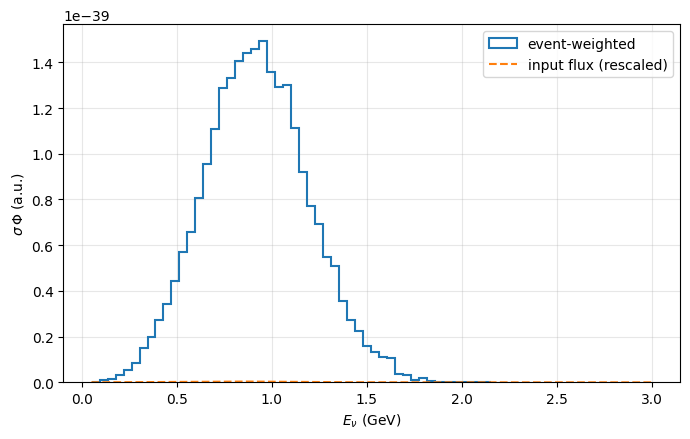

In [8]:
def flux_numu(E):
    return np.exp(-((E - 0.8) ** 2) / (2 * 0.3**2))

sm_mu = nep.NuElectronSMModel(nu_flavor='mu')
proc = nep.NuElectronProcess(sm_mu, Emin=0.05, Emax=3.0, flux=flux_numu, T_min=0.05)
print(f'flux-averaged xsec (T_e > 50 MeV): {proc.flux_avg_xsec():.3e} cm^2')

gen = nep.NuElectronGenerator(
    sm_mu, Emin=0.05, Emax=3.0, flux=flux_numu, T_min=0.05,
    n_events=20_000, seed=0,
)
df_flux = gen.generate()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df_flux[('Enu', '')], bins=50,
        weights=df_flux[('w_event_rate', '')],
        histtype='step', label='event-weighted', lw=1.5)
Egrid = np.linspace(0.05, 3.0, 200)
ax.plot(Egrid, flux_numu(Egrid) * np.max(df_flux[('w_event_rate','')].values) /
        flux_numu(Egrid).max(),
        ls='--', label='input flux (rescaled)')
ax.set_xlabel(r'$E_\nu$ (GeV)')
ax.set_ylabel(r'$\sigma\,\Phi$ (a.u.)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## 6) Reference

* The SM cross-section formulas follow Vogel & Engel, Phys. Rev. D 39 (1989) 3378, with $\sin^2\theta_W = 0.2223$.
* The BSM extension follows the standard treatment of a light vector $Z'$ that contributes additively to $C_v$ via its propagator at $t = -2 m_e T_e$.
* The DataFrame schema (`P_projectile`, `P_target`, `P_decay_ell_minus`, `P_decay_N_daughter`, `w_event_rate`, `target`, `scattering_regime`) matches DarkNews so downstream analysis code can be reused.